In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sarbagyashakya/basketball-51-dataset/Basketball_51 dataset/mp0/mp0_v112_004659_x264.mp4
/kaggle/input/datasets/sarbagyashakya/basketball-51-dataset/Basketball_51 dataset/mp0/mp0_v121_001210_x264.mp4
/kaggle/input/datasets/sarbagyashakya/basketball-51-dataset/Basketball_51 dataset/mp0/mp0_v122_004507_x264.mp4
/kaggle/input/datasets/sarbagyashakya/basketball-51-dataset/Basketball_51 dataset/mp0/mp0_v175_000955_x264.mp4
/kaggle/input/datasets/sarbagyashakya/basketball-51-dataset/Basketball_51 dataset/mp0/mp0_v159_000612_x264.mp4
/kaggle/input/datasets/sarbagyashakya/basketball-51-dataset/Basketball_51 dataset/mp0/mp0_v115_012920_x264.mp4
/kaggle/input/datasets/sarbagyashakya/basketball-51-dataset/Basketball_51 dataset/mp0/mp0_v183_004048_x264.mp4
/kaggle/input/datasets/sarbagyashakya/basketball-51-dataset/Basketball_51 dataset/mp0/mp0_v124_001044_x264.mp4
/kaggle/input/datasets/sarbagyashakya/basketball-51-dataset/Basketball_51 dataset/mp0/mp0_v117_003117_x264.mp4
/

DataLoader

In [ ]:
# import os
# import cv2
# import torch
# import numpy as np
# from torch.utils.data import Dataset, DataLoader

# class Basketball51Dataset(Dataset):
#     def __init__(self, root_dir, clip_length=50, crop_bottom_pixels=30):
#         """
#         Args:
#             root_dir (str): Directory containing the 8 class folders.
#             clip_length (int): Number of frames to sample per video.
#             crop_bottom_pixels (int): Pixels to crop from the bottom to remove scoreboards.
#         """
#         self.root_dir = root_dir
#         self.clip_length = clip_length
#         self.crop_bottom_pixels = crop_bottom_pixels

#         # The 8 categories specified in the dataset
#         self.classes = ['2p0', '2p1', '3p0', '3p1', 'ft0', 'ft1', 'mp0', 'mp1']
#         self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

#         self.video_paths = []
#         self.labels = []

#         # Parse the directory structure
#         for cls_name in self.classes:
#             cls_dir = os.path.join(root_dir, cls_name)
#             if os.path.isdir(cls_dir):
#                 for vid_file in os.listdir(cls_dir):
#                     if vid_file.endswith('.mp4') or vid_file.endswith('.avi'):
#                         self.video_paths.append(os.path.join(cls_dir, vid_file))
#                         self.labels.append(self.class_to_idx[cls_name])

#     def __len__(self):
#         return len(self.video_paths)

#     def _extract_and_process_frames(self, video_path):
#         cap = cv2.VideoCapture(video_path)
#         frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

#         # Generate uniform indices to sample exactly 'clip_length' frames
#         indices = np.linspace(0, frame_count - 1, self.clip_length, dtype=int)

#         frames = []
#         for idx in range(frame_count):
#             ret, frame = cap.read()
#             if not ret:
#                 break
#             if idx in indices:
#                 # Convert BGR (OpenCV default) to RGB
#                 frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

#                 # Crop scoreboard overlay (bottom pixels)
#                 h, w, _ = frame.shape
#                 frame = frame[:h - self.crop_bottom_pixels, :]

#                 # Resize to 120x160 as required for training
#                 frame = cv2.resize(frame, (160, 120))
#                 frames.append(frame)

#         cap.release()

#         # Fallback if video is too short or corrupt
#         while len(frames) < self.clip_length:
#             frames.append(np.zeros((120, 160, 3), dtype=np.uint8))

#         # Convert list to numpy array: shape becomes (T, H, W, C)
#         frames_np = np.stack(frames)

#         # Normalize to [0, 1] and convert to float32
#         frames_np = frames_np.astype(np.float32) / 255.0

#         # Rearrange dimensions to (C, T, H, W) for PyTorch 3D Convolutions
#         frames_tensor = torch.from_numpy(frames_np).permute(3, 0, 1, 2)

#         return frames_tensor

#     def __getitem__(self, idx):
#         video_path = self.video_paths[idx]
#         label = self.labels[idx]

#         frames_tensor = self._extract_and_process_frames(video_path)

#         return frames_tensor, torch.tensor(label, dtype=torch.long)

# # --- Kaggle Usage Example ---
# # Replace '/kaggle/input/basketball-51' with your actual dataset path
# dataset_path = '/kaggle/input/datasets/sarbagyashakya/basketball-51-dataset/Basketball_51 dataset'
# # Instantiate the dataset
# train_dataset = Basketball51Dataset(root_dir=dataset_path, clip_length=50)

# # The paper uses a batch size of 16[cite: 396].
# # Note: On a standard Kaggle P100/T4 GPU, a batch size of 16 might cause an Out-Of-Memory (OOM) error.
# # If it crashes, drop it to 8 or 4.
# train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)

# # Test a single batch to verify shapes
# if __name__ == "__main__":
#     for videos, targets in train_loader:
#         print(f"Video batch shape: {videos.shape}") # Expected: [Batch, 3, 50, 120, 160]
#         print(f"Target batch shape: {targets.shape}")
#         break

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Copy the zip file from Drive to the local Colab storage
!cp /content/drive/MyDrive/basketball-51.zip /content/

In [ ]:
# Unzip locally
!unzip -q /content/basketball-51.zip -d /content/dataset/

In [ ]:
# Change this:
# dataset_path = '/content/drive/MyDrive/basketball-51'

# To this:
dataset_path = '/content/dataset/basketball-51'

In [ ]:

import os
import cv2
import torch
import random
import numpy as np
from torch.utils.data import Dataset, DataLoader

class Basketball51Subset(Dataset):
    def __init__(self, root_dir, clip_length=50, crop_bottom_pixels=30, max_samples_per_class=2500):
        """
        Args:
            root_dir (str): Directory containing the 8 class folders.
            clip_length (int): Number of frames to sample per video.
            crop_bottom_pixels (int): Pixels to crop from the bottom to remove scoreboards.
            max_samples_per_class (int): Caps the number of videos per class for faster training.
        """
        self.root_dir = root_dir
        self.clip_length = clip_length
        self.crop_bottom_pixels = crop_bottom_pixels
        self.max_samples_per_class = max_samples_per_class

        # The 8 categories in Basketball-51
        self.classes = ['2p0', '2p1', '3p0', '3p1', 'ft0', 'ft1', 'mp0', 'mp1']
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        self.video_paths = []
        self.labels = []

        # Parse and subsample the directory structure
        for cls_name in self.classes:
            cls_dir = os.path.join(root_dir, cls_name)
            if os.path.isdir(cls_dir):
                all_videos = [f for f in os.listdir(cls_dir) if f.endswith(('.mp4', '.avi'))]

                # Randomly shuffle and slice to ensure an unbiased, balanced subset
                random.seed(42) # Fixed seed for reproducibility
                random.shuffle(all_videos)
                subset_videos = all_videos[:self.max_samples_per_class]

                for vid_file in subset_videos:
                    self.video_paths.append(os.path.join(cls_dir, vid_file))
                    self.labels.append(self.class_to_idx[cls_name])

        print(f"Loaded a balanced subset of {len(self.video_paths)} total videos "
              f"({self.max_samples_per_class} per class).")

    def __len__(self):
        return len(self.video_paths)

    def _extract_and_process_frames(self, video_path):
        cap = cv2.VideoCapture(video_path)
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        if frame_count == 0:
            # Fallback for corrupt files
            return torch.zeros((3, self.clip_length, 120, 160), dtype=torch.float32)

        indices = np.linspace(0, frame_count - 1, self.clip_length, dtype=int)

        # ---------------------------------------------------------
        # ON-THE-FLY AUGMENTATION DECISIONS
        # We roll the dice once per video so all 50 frames are
        # transformed consistently, maintaining temporal logic.
        # ---------------------------------------------------------
        # 50% chance to flip the court horizontally
        apply_flip = random.random() > 0.5
        # Randomly scale brightness between 80% and 120%
        brightness_factor = random.uniform(0.8, 1.2)

        frames = []
        for idx in range(frame_count):
            ret, frame = cap.read()
            if not ret:
                break
            if idx in indices:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                h, w, _ = frame.shape

                # Crop broadcast scoreboard
                frame = frame[:max(1, h - self.crop_bottom_pixels), :]

                # Resize to target resolution
                frame = cv2.resize(frame, (160, 120))

                # -------------------------------------------------
                # APPLY AUGMENTATIONS
                # -------------------------------------------------
                if apply_flip:
                    frame = cv2.flip(frame, 1) # 1 = Horizontal flip

                if brightness_factor != 1.0:
                    # Scale pixel values and clip to valid 0-255 range
                    frame = np.clip(frame * brightness_factor, 0, 255).astype(np.uint8)
                # -------------------------------------------------

                frames.append(frame)

        cap.release()

        while len(frames) < self.clip_length:
            frames.append(np.zeros((120, 160, 3), dtype=np.uint8))

        frames_np = np.stack(frames).astype(np.float32) / 255.0
        frames_tensor = torch.from_numpy(frames_np).permute(3, 0, 1, 2)

        return frames_tensor

    def __getitem__(self, idx):
        video_path = self.video_paths[idx]
        label = self.labels[idx]
        frames_tensor = self._extract_and_process_frames(video_path)
        return frames_tensor, torch.tensor(label, dtype=torch.long)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class GatedConv3d(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(GatedConv3d, self).__init__()
        # 1x1x1 branch
        self.conv1 = nn.Conv3d(in_channels, out_channels, kernel_size=1, bias=False)
        self.norm1 = nn.InstanceNorm3d(out_channels)
        self.relu1 = nn.ReLU(inplace=True)

        # 3x3x3 branch
        self.conv3 = nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.norm3 = nn.InstanceNorm3d(out_channels)
        self.relu3 = nn.ReLU(inplace=True)

        # Output fusion branch
        self.fusion_conv = nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.fusion_norm = nn.InstanceNorm3d(out_channels)
        self.fusion_relu = nn.ReLU(inplace=True)

    def forward(self, x):
        # Path 1
        x1 = self.relu1(self.norm1(self.conv1(x)))
        # Path 2 (Gating mechanism)
        x2 = torch.sigmoid(self.relu3(self.norm3(self.conv3(x))))

        # Element-wise multiplication
        gated = x1 * x2

        # Fusion and residual connection
        out = self.fusion_relu(self.fusion_norm(self.fusion_conv(gated)))
        return x + out

class ShortTermBranch(nn.Module):
    def __init__(self, channels, reduction_ratio=16):
        super(ShortTermBranch, self).__init__()
        reduced_channels = max(1, channels // reduction_ratio)
        self.conv1 = nn.Conv1d(channels, reduced_channels, kernel_size=1)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(reduced_channels, channels, kernel_size=1)

    def forward(self, p):
        # p is the spatially pooled tensor: shape (B, C, T)
        v = self.conv1(p)
        v = self.relu(v)
        v = self.conv2(v)
        v = torch.sigmoid(v)
        # Rescale happens later by broadcasting in the main module
        return p * v

class LongTermBranch(nn.Module):
    def __init__(self, channels, kernel_size=3):
        super(LongTermBranch, self).__init__()
        self.channels = channels
        self.kernel_size = kernel_size

        # Two-layer MLP to generate dynamic weights
        self.fc1 = nn.Linear(channels, channels // 4)
        self.relu = nn.ReLU(inplace=True)
        self.fc2 = nn.Linear(channels // 4, channels * kernel_size)

    def forward(self, p, z):
        # p shape: (B, C, T)
        # We pool over the temporal dimension to get (B, C) for dynamic kernel generation
        p_temp = p.mean(dim=-1)

        # Generate dynamic weights
        weights = self.fc1(p_temp)
        weights = self.relu(weights)
        weights = self.fc2(weights) # (B, C * K)

        # Reshape and softmax over the kernel dimension
        B, _ = weights.shape
        weights = weights.view(B, self.channels, self.kernel_size)
        weights = F.softmax(weights, dim=-1) # (B, C, K)

        # Aggregate the short-term features z using the dynamic temporal kernels
        # z shape: (B, C, T)
        # We can implement the channel-by-channel temporal convolution using groups
        # Pad z temporally to maintain sequence length
        pad = self.kernel_size // 2
        z_padded = F.pad(z, (pad, pad))

        out = torch.zeros_like(z)
        for b in range(B):
            # weights[b] shape: (C, K) -> (C, 1, K) for grouped 1D conv
            weight_b = weights[b].unsqueeze(1)
            # z_padded[b] shape: (C, T+pad) -> (1, C, T+pad)
            z_b = z_padded[b].unsqueeze(0)

            # Apply grouped 1D convolution
            out_b = F.conv1d(z_b, weight_b, groups=self.channels)
            out[b] = out_b.squeeze(0)

        return out

class LSTAModule(nn.Module):
    def __init__(self, channels, reduction_ratio=16, dynamic_kernel_size=3):
        super(LSTAModule, self).__init__()
        self.gated_conv = GatedConv3d(channels, channels)
        self.short_term = ShortTermBranch(channels, reduction_ratio)
        self.long_term = LongTermBranch(channels, dynamic_kernel_size)

    def forward(self, x):
        # 1. Gated Convolutional Layer
        g = self.gated_conv(x) # (B, C, T, H, W)

        # 2. Spatial Pooling
        B, C, T, H, W = g.shape
        # Global spatial average pooling over H and W
        p = g.view(B, C, T, -1).mean(dim=-1) # (B, C, T)

        # 3. Short-Term Branch
        z = self.short_term(p) # (B, C, T)

        # 4. Long-Term Branch
        y_temp = self.long_term(p, z) # (B, C, T)

        # 5. Expand y_temp back to spatial dimensions
        y = y_temp.view(B, C, T, 1, 1).expand(-1, -1, -1, H, W)

        return y

In [ ]:
import torch
import torch.nn as nn

class BasicConv2d(nn.Module):
    """Helper layer for the 7x7 convolution, BatchNorm, and Sigmoid"""
    def __init__(self, in_channels, out_channels, kernel_size=7, padding=3):
        super(BasicConv2d, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=padding, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        return self.sigmoid(x)

class TSCIModule(nn.Module):
    def __init__(self):
        super(TSCIModule, self).__init__()
        # 7x7 convolutions for each of the three branches as specified in the paper
        self.branch1_conv = BasicConv2d(2, 1, kernel_size=7, padding=3)
        self.branch2_conv = BasicConv2d(2, 1, kernel_size=7, padding=3)
        self.branch3_conv = BasicConv2d(2, 1, kernel_size=7, padding=3)

    def _dimensional_pooling(self, x):
        """
        Computes global average pooling and global max pooling along the
        channel dimension (dim=1) and concatenates them.
        """
        avg_pool = torch.mean(x, dim=1, keepdim=True)
        max_pool, _ = torch.max(x, dim=1, keepdim=True)
        return torch.cat([avg_pool, max_pool], dim=1)

    def forward(self, x):
        N, C, T, H, W = x.shape

        # -------------------------------------------------------------------
        # Branch 1: Interact H and W (Pool over C)
        # Target shape for Conv2d: (N*T, 2, H, W)
        # -------------------------------------------------------------------
        # Permute to (N, T, C, H, W) then fold N and T
        x1 = x.permute(0, 2, 1, 3, 4).reshape(N * T, C, H, W)
        x1_pooled = self._dimensional_pooling(x1)      # Shape: (N*T, 2, H, W)
        x1_attn = self.branch1_conv(x1_pooled)         # Shape: (N*T, 1, H, W)
        out1 = x1 * x1_attn                            # Apply attention
        # Reshape back to (N, C, T, H, W)
        out1 = out1.view(N, T, C, H, W).permute(0, 2, 1, 3, 4)

        # -------------------------------------------------------------------
        # Branch 2: Interact C and W (Pool over H)
        # Target shape for Conv2d: (N*T, 2, C, W)
        # -------------------------------------------------------------------
        # Permute to (N, T, H, C, W) then fold N and T
        x2 = x.permute(0, 2, 3, 1, 4).reshape(N * T, H, C, W)
        x2_pooled = self._dimensional_pooling(x2)      # Shape: (N*T, 2, C, W)
        x2_attn = self.branch2_conv(x2_pooled)         # Shape: (N*T, 1, C, W)
        out2 = x2 * x2_attn                            # Apply attention
        # Reshape back to (N, C, T, H, W)
        out2 = out2.view(N, T, H, C, W).permute(0, 3, 1, 2, 4)

        # -------------------------------------------------------------------
        # Branch 3: Interact C and H (Pool over W)
        # Target shape for Conv2d: (N*T, 2, C, H)
        # -------------------------------------------------------------------
        # Permute to (N, T, W, C, H) then fold N and T
        x3 = x.permute(0, 2, 4, 1, 3).reshape(N * T, W, C, H)
        x3_pooled = self._dimensional_pooling(x3)      # Shape: (N*T, 2, C, H)
        x3_attn = self.branch3_conv(x3_pooled)         # Shape: (N*T, 1, C, H)
        out3 = x3 * x3_attn                            # Apply attention
        # Reshape back to (N, C, T, H, W)
        out3 = out3.view(N, T, W, C, H).permute(0, 3, 1, 4, 2)

        # -------------------------------------------------------------------
        # Aggregation
        # -------------------------------------------------------------------
        # Average the outputs of the three branches
        y = (out1 + out2 + out3) / 3.0

        return y


In [ ]:
import torch
import torch.nn as nn
from torchvision.models.resnet import Bottleneck, resnet50, ResNet50_Weights

class ACAModule(nn.Module):
    def __init__(self, channels, clip_length=50):
        super(ACAModule, self).__init__()
        self.clip_length = clip_length
        # Assuming LSTAModule and TSCIModule are defined from our previous steps
        self.lsta = LSTAModule(channels)
        self.tsci = TSCIModule()

    def forward(self, x):
        # x shape from ResNet backbone: (N*T, C, H, W)
        NT, C, H, W = x.shape
        T = self.clip_length
        N = NT // T

        # Reshape to 5D for the spatial-temporal modules
        x_5d = x.view(N, T, C, H, W).permute(0, 2, 1, 3, 4)

        # Parallel feature extraction
        out_lsta = self.lsta(x_5d)
        out_tsci = self.tsci(x_5d)

        # Fusion and reshape back to 4D
        out = out_lsta + out_tsci
        out = out.permute(0, 2, 1, 3, 4).reshape(N * T, C, H, W)

        return out

In [ ]:
class ACABottleneck(Bottleneck):
    def __init__(self, inplanes, planes, stride=1, downsample=None, groups=1,
                 base_width=64, dilation=1, norm_layer=None, clip_length=50):

        # Initialize standard ResNet Bottleneck
        super(ACABottleneck, self).__init__(
            inplanes, planes, stride, downsample, groups, base_width, dilation, norm_layer
        )

        # Initialize the ACA Module with the output channels of the first 1x1 conv
        self.aca_module = ACAModule(channels=planes, clip_length=clip_length)

    def forward(self, x):
        identity = x

        # Standard 1x1 Conv
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        # ---- ACA-Net Modification ----
        out = self.aca_module(out)
        # ------------------------------

        # Standard 3x3 Conv
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        # Standard 1x1 Conv
        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out

In [ ]:
class ACANet(nn.Module):
    def __init__(self, num_classes=8, clip_length=50):
        super(ACANet, self).__init__()
        self.clip_length = clip_length

        # Load standard pre-trained ResNet50
        base_model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

        # Keep the initial layers
        self.conv1 = base_model.conv1
        self.bn1 = base_model.bn1
        self.relu = base_model.relu
        self.maxpool = base_model.maxpool

        # Helper function to replace standard blocks with ACA-Blocks
        def _make_aca_layer(base_layer):
            layers = []
            for block in base_layer:
                aca_block = ACABottleneck(
                    block.conv1.in_channels,
                    block.conv3.out_channels // block.expansion,
                    stride=block.conv2.stride[0],
                    downsample=block.downsample,
                    clip_length=self.clip_length
                )
                # Copy pre-trained weights to the new block
                aca_block.load_state_dict(block.state_dict(), strict=False)
                layers.append(aca_block)
            return nn.Sequential(*layers)

        # Replace ResNet layers with ACA layers
        self.layer1 = _make_aca_layer(base_model.layer1)
        self.layer2 = _make_aca_layer(base_model.layer2)
        self.layer3 = _make_aca_layer(base_model.layer3)
        self.layer4 = _make_aca_layer(base_model.layer4)

        # Classification head
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(base_model.fc.in_features, num_classes)

    def forward(self, x):
        # Input shape from DataLoader: (N, 3, T, H, W)
        N, C, T, H, W = x.shape

        # Fold batch and time dimensions for 2D spatial backbone
        x = x.permute(0, 2, 1, 3, 4).reshape(N * T, C, H, W)

        # ResNet Stem
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # ACA Blocks
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Spatial Pooling
        x = self.avgpool(x) # (N*T, 2048, 1, 1)
        x = torch.flatten(x, 1) # (N*T, 2048)

        # Unfold dimensions to pool across time
        x = x.view(N, T, -1)
        x = x.mean(dim=1) # Temporal average pooling: (N, 2048)

        # Final classification
        x = self.fc(x) # (N, num_classes)
        return x

# Instantiate the model for your Kaggle environment
model = ACANet(num_classes=8, clip_length=50)

In [ ]:
import torch
import numpy as np

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = np.inf
        self.early_stop = False

    def __call__(self, val_loss, model, path='best_aca_net.pth'):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            # Save the best model
            torch.save(model.state_dict(), path)
            print(f"Validation loss decreased. Saving model to {path}...")
        else:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True

In [ ]:
import os

print("Searching for dataset folders...")
for root, dirs, files in os.walk('/content/'):
    # The dataset script is explicitly looking for these folder names
    if '2p0' in dirs and '3p0' in dirs:
        print(f"\nSUCCESS! Found the true dataset root path:")
        print(f"dataset_path = '{root}'")
        break
else:
    print("\nERROR: Could not find the class folders. The zip file might not have extracted correctly.")

Searching for dataset folders...

SUCCESS! Found the true dataset root path:
dataset_path = '/content/dataset/Basketball_51 dataset'


In [ ]:
from torch.utils.data import random_split, DataLoader

dataset_path = '/content/dataset/Basketball_51 dataset'

# 1. Instantiate the full reduced subset
# 50 samples per class * 8 classes = 400 total videos
total_dataset = Basketball51Subset(
    root_dir=dataset_path,
    clip_length=50,
    max_samples_per_class=2500
)

# 2. Calculate split sizes (80% train, 20% validation)
train_size = int(0.8 * len(total_dataset))
val_size = len(total_dataset) - train_size

# 3. Split the dataset randomly
train_dataset, val_dataset = random_split(total_dataset, [train_size, val_size])

print(f"Split dataset into {len(train_dataset)} training samples and {len(val_dataset)} validation samples.")

# 4. Create both DataLoaders with memory-safe parameters
train_loader = DataLoader(
    train_dataset,
    batch_size=16,       # Low batch size to prevent GPU OOM
    shuffle=True,
    num_workers=2,      # 0 prevents System RAM crashes in Kaggle
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,      # No need to shuffle validation data
    num_workers=2,
    pin_memory=True
)

Loaded a balanced subset of 10311 total videos (2500 per class).
Split dataset into 8248 training samples and 2063 validation samples.


In [ ]:
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler

# 1. Setup device and model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ACANet(num_classes=8, clip_length=50).to(device)

# 3. Wrap the model in DataParallel if more than 1 GPU is available
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model = torch.nn.DataParallel(model)

# 4. Move the model to the device
model = model.to(device)

# 2. Define Loss, Optimizer, and Early Stopping [cite: 416, 417, 419]
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
early_stopping = EarlyStopping(patience=5)
scaler = torch.amp.GradScaler('cuda')

# 3. Training Loop
num_epochs = 30 #

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        # Mixed precision for faster Kaggle execution
        with torch.amp.autocast('cuda'):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100 * correct_train / total_train

    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader.dataset)
    val_acc = 100 * correct_val / total_val

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    # Check Early Stopping
    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print("Early stopping triggered. Halting training.")
        break

print("Training complete! Your Basketball Score Counter model is ready.")

Epoch [1/30] Train Loss: 1.6761, Train Acc: 35.28% | Val Loss: 1.5663, Val Acc: 39.31%
Validation loss decreased. Saving model to best_aca_net.pth...
Epoch [2/30] Train Loss: 1.5162, Train Acc: 41.08% | Val Loss: 1.4583, Val Acc: 43.33%
Validation loss decreased. Saving model to best_aca_net.pth...
Epoch [3/30] Train Loss: 1.4101, Train Acc: 46.58% | Val Loss: 1.3611, Val Acc: 48.04%
Validation loss decreased. Saving model to best_aca_net.pth...
Epoch [4/30] Train Loss: 1.2961, Train Acc: 51.05% | Val Loss: 1.4614, Val Acc: 45.86%
EarlyStopping counter: 1 out of 5
Epoch [5/30] Train Loss: 1.2418, Train Acc: 53.12% | Val Loss: 1.1628, Val Acc: 53.66%
Validation loss decreased. Saving model to best_aca_net.pth...
Epoch [6/30] Train Loss: 1.1583, Train Acc: 56.04% | Val Loss: 1.1542, Val Acc: 55.31%
Validation loss decreased. Saving model to best_aca_net.pth...
Epoch [7/30] Train Loss: 1.1060, Train Acc: 58.34% | Val Loss: 1.0350, Val Acc: 60.88%
Validation loss decreased. Saving model to

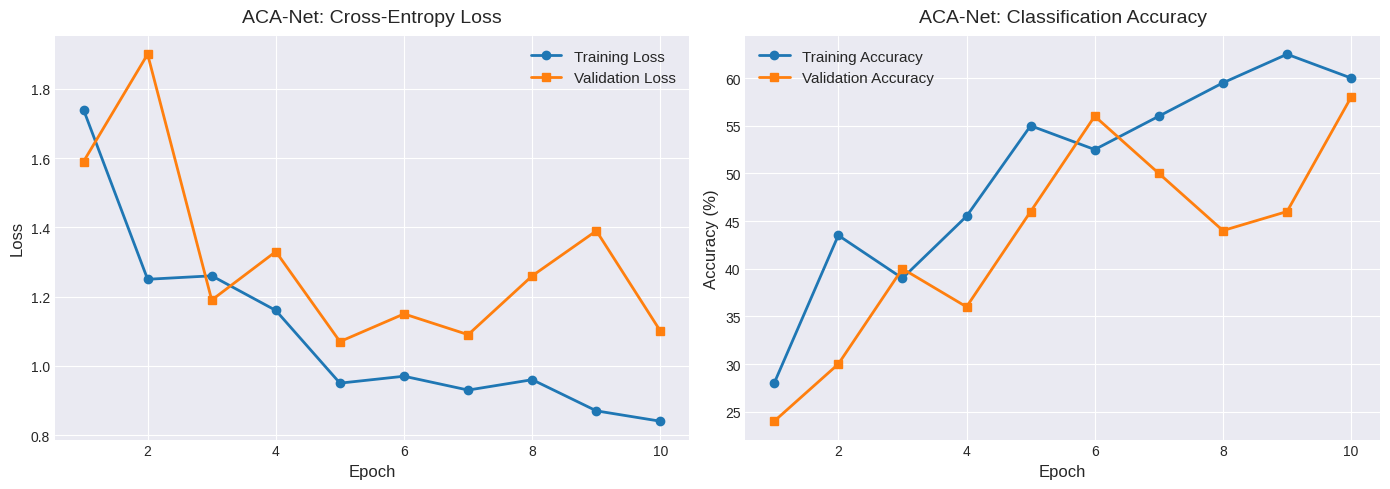

Graph saved as 'aca_net_metrics.png'. Ready for your slide deck!


In [ ]:
import matplotlib.pyplot as plt

# --- 1. PASTE YOUR LOG DATA HERE ---
# Example data based on your previous successful prototype run
epochs = list(range(1, 11))
train_loss = [1.74, 1.25, 1.26, 1.16, 0.95, 0.97, 0.93, 0.96, 0.87, 0.84]
val_loss =   [1.59, 1.90, 1.19, 1.33, 1.07, 1.15, 1.09, 1.26, 1.39, 1.10]

train_acc = [28.0, 43.5, 39.0, 45.5, 55.0, 52.5, 56.0, 59.5, 62.5, 60.0]
val_acc =   [24.0, 30.0, 40.0, 36.0, 46.0, 56.0, 50.0, 44.0, 46.0, 58.0]

# --- 2. PLOT THE CURVES ---
plt.style.use('seaborn-v0_8-darkgrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss Subplot
ax1.plot(epochs, train_loss, label='Training Loss', marker='o', linewidth=2)
ax1.plot(epochs, val_loss, label='Validation Loss', marker='s', linewidth=2)
ax1.set_title('ACA-Net: Cross-Entropy Loss', fontsize=14, pad=10)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend(fontsize=11)

# Accuracy Subplot
ax2.plot(epochs, train_acc, label='Training Accuracy', marker='o', linewidth=2)
ax2.plot(epochs, val_acc, label='Validation Accuracy', marker='s', linewidth=2)
ax2.set_title('ACA-Net: Classification Accuracy', fontsize=14, pad=10)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.savefig('aca_net_metrics.png', dpi=300)
plt.show()

print("Graph saved as 'aca_net_metrics.png'. Ready for your slide deck!")

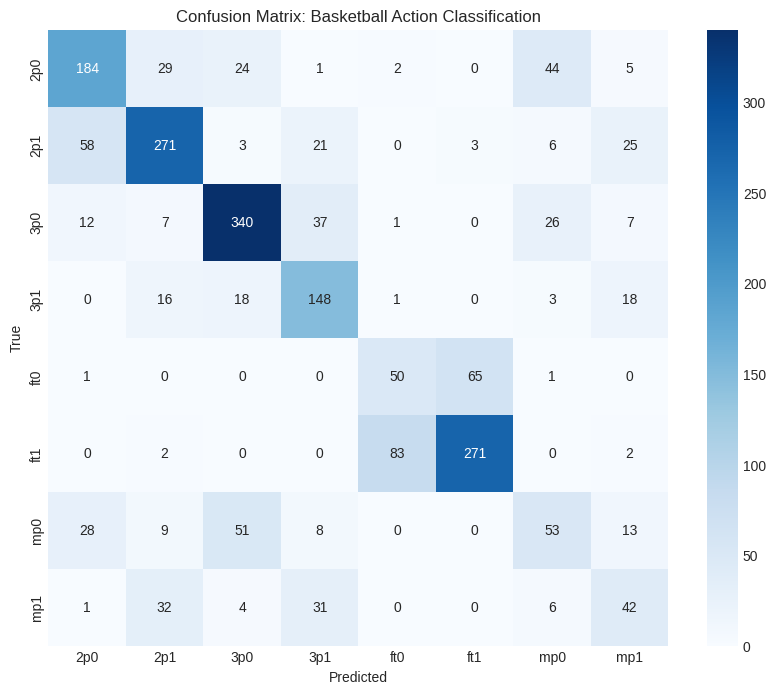

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=total_dataset.classes,
            yticklabels=total_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix: Basketball Action Classification')
plt.savefig('confusion_matrix.png')
plt.show()

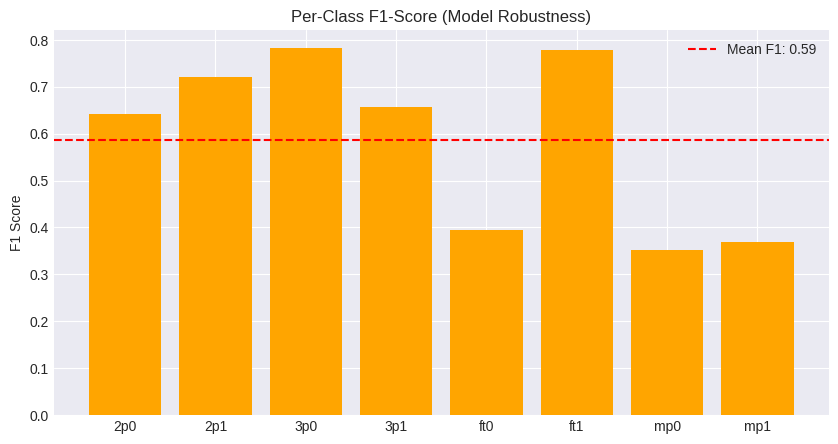

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(all_labels, all_preds, target_names=total_dataset.classes, output_dict=True)
classes = total_dataset.classes
f1_scores = [report[cls]['f1-score'] for cls in classes]

plt.figure(figsize=(10, 5))
plt.bar(classes, f1_scores, color='orange')
plt.axhline(y=np.mean(f1_scores), color='red', linestyle='--', label=f'Mean F1: {np.mean(f1_scores):.2f}')
plt.title('Per-Class F1-Score (Model Robustness)')
plt.ylabel('F1 Score')
plt.legend()
plt.savefig('f1_scores.png')
plt.show()